In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

텍스트 분석에 널리 쓰이는 분석 방법인 단어 가방(Bag Of Words, BOW) 모형과 TF-IDF(Term Frequency-Inverse Document Frequency) 방법을 살펴본다. 단어 가방 모형은 단어의 순서를 고려하지 않고 중복 발생 빈도를 중요하게 취급하는 방법이다. 단어 가방이라는 비유적 표현을 사용한 것은 주머니에서 공을 꺼내거나 가방에서 단어 카드를 꺼내는 방식처럼 계산하기 때문이다. TF-IDF에서 TF나 IDF도 출현 빈도를 고려새 가중치를 적용하는 방법이다.

# 단어 가방 모형

단어 가방 모형이라는 표현은 1954년 젤리그 해리스(Zellig Harris)의 논문에서 처음 사용됐다. 비교적 간단하게 단어를 벡터로 표현해 주어진 텍스트의 특징을 설며할 수 있다는 점은 널리 쓰일 만한 큰 장점이다. 다만, 단어의 빈도수는 같으나 단어의 순서가 중요한 문장이나. 부정 표현이 있는 문장 등에 의미를 세밀하게 구별하기 어렵다는 단점이 있다.

쉽게 성공했다고 생각하지 않는다. => 어렵게 성공했다.  
성공하지 않았다고 생각하기 쉽다. => 성공했다.  
쉽게 생각해도 성공한 것은 아니다. => 실패했다.

위 문장들은 '쉽다, 성공하다, 생각하다 + 부정 표현'의 어순 배열을 달리한 것인데, 단어의 위치에 따라 의미가 완전히 달라진다. 이와 같은 단점을 보완하기 위해 n-gram, min_df, max_df 등의 기법이 사용된다.

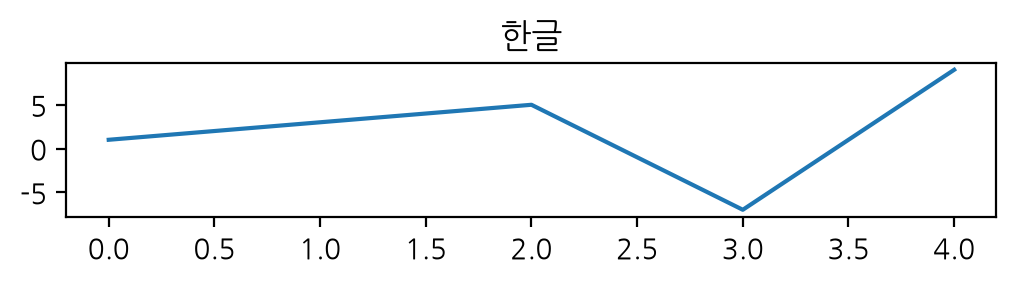

In [2]:
# 주피터 노트북이나 주피터랩 환경 및 코랩 환경에서 맷플롯립(Matplotlib)을 사용해 그래프를 그릴 때, 그래프의 해상도(선명도)를 높여주는 설정 코드
%config InlineBackend.figure_format = 'retina' # 그래프에 retina display를 적용한다.
pd.Series([1, 3, 5, -7, 9]).plot(title='한글', figsize=(6, 1))
plt.show()

분석할 데이터를 말뭉치(corpus)에 저장한다.

In [3]:
corpus = [
    '코로나 거리두기와 코로나 상생지원금 문의입니다.',
    '지하철 운행시간과 지하철 요금 문의입니다.',
    '지하철 승강장 문의입니다.',
    '택시 승강장 문의입니다.'
]
corpus

['코로나 거리두기와 코로나 상생지원금 문의입니다.',
 '지하철 운행시간과 지하철 요금 문의입니다.',
 '지하철 승강장 문의입니다.',
 '택시 승강장 문의입니다.']

# 단어 가방 모형 만들기

데이터가 완성됐으므로 sklearn의 CountVectorizer를 사용해서 BOW 인코딩 벡터를 만든다.

CountVectorizer의 주요 매개변수 

`analyzer`: 단어(word, 기본값), 문자(char) 단위 벡터화 방법을 정의한다.  
`ngram_range`: 기본값은 (1, 1), BOW 단위수가 (1, 3)라면 1 ~ 3개까지 토큰을 묶어서 벡터화한다.  
`max_df`: 기본값은 1.0으로 100%를 의미한다. 주어진 속성값보다 빈도수가 높은 단어(불용어)를 제외하는 방법을 지정한다.  
&nbsp;&nbsp;&nbsp;max_df=0.9: 전체 문서 중 90% '초과'의 문서에 출현한 단어는 어휘 사전에서 제외한다.  
&nbsp;&nbsp;&nbsp;max_df=10: 10개를 '초과'해서 문서에 출현한 단어는 어휘 사전에서 제외한다.  
`min_df`: 기본값은 1.0으로 100%를 의미한다. 주어진 속성값보다 빈도수가 낮은 단어(불용어)를 제외하는 방법을 지정한다.  
&nbsp;&nbsp;&nbsp;min_df=0.1: 전체 문서 중 10% '미만'의 문서에 출현한 단어는 어휘 사전에서 제외한다.  
&nbsp;&nbsp;&nbsp;min_df=3: 3개를 '미만'해서 문서에 출현한 단어는 어휘 사전에서 제외한다.  
`max_features`:  기본값은 None이고, 학습할 단어 사전의 어휘 개수를 지정한다.  
`stop_words`: min_df 속성과 min_df를 무시하고 불용어를 정의한다.  

In [4]:
import sklearn
sklearn.set_config(display='text')
from sklearn.feature_extraction.text import CountVectorizer

사이킷런에서 단어를 학습할 때는 fit(), transform(), fit_transform() 메소드를 사용한다.  
`fit()`: 문서에 있는 모든 단어 사전을 학습한다.  
`transform()`: 학습한 결과를 적용(문서를 단어와 문서 행렬로 변환)한다. transform() 이후에는 행렬로 변환되어 숫자 형태로 변경된다.  
`fit_transform()`: 학습과 적용을 한 번에 실행한다. 단, fit_transform()는 학습 데이터에만 사용해야 하고 테스트 데이터에서는 사용하면 안된다.

||fit(), transform()|fit_transform()|
|:---|:---|:---|
|학습 세트|fit()과 transform()을 각각 사용|fit_transform() 메소드로 사용|
|시험 세트|transform()|transform()|
|비고|fit()을 통해 단어 사전을 학습하고 transform()으로 변환|학습과 변환을 한 번에 해 준다는 장점이 있지만, 같은 이유로 시험 데이터 세트에는 사용할 수 없고 학습 데이터 세트에만 사용해야 한다.|
|||학습과 변환을 한꺼번에 해서 시험 데이터를 평가한다면 시험 데이터를 학습한 후에 다시 테스트하는 일종의 시험지 미리 보기 같은 결과를 가져오기 때문이다.|

학습, 테스트 데이터의 단어 사전의 내용과 순서가 제각각이라면 단어 가방 모형을 만들어도 제대로 학습할 수 없다. 따라서 단어 가방 모형을 만들 때는 학습 데이터와 테스트 데이터로 나눈 뒤 학습 데이터를 기준으로 만든다. 그래야 테스트 데이터에만 있는 단어가 단어 사전에 포함되지 않는다.

문장에서 노출되는 feature(특징이 될 만한 단어) 수를 합한 문서 단어 행렬(Document Term Matrix, DTM)을 반환하고, fit() 메소드로 문서에 있는 모든 단어 사전을 학습시킨다. 학습된 결과를 transform() 메소드로 문서를 단어 빈도수가 들어있는 문서 단어 행렬로 변환한다.

In [5]:
cvect = CountVectorizer()
# cvect.fit(corpus) # 학습 시킨다.
# dtm = cvect.transform(corpus) # 적용 시킨다.
dtm = cvect.fit_transform(corpus) # 학습 후 적용시킨다.
dtm 

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 14 stored elements and shape (4, 9)>

실행 결과를 보면 4 * 9 희소 행렬(Compressed Sparse Row, 행렬의 값이 대부분 '0'인 행렬)이 출력됐음을 알 수 있다.

단어 희소 행렬이 생성됐다면 vocabulary_ 속성으로 단어 사전을 볼 수 있다.

In [6]:
cvect.vocabulary_

{'코로나': 7,
 '거리두기와': 0,
 '상생지원금': 2,
 '문의입니다': 1,
 '지하철': 6,
 '운행시간과': 5,
 '요금': 4,
 '승강장': 3,
 '택시': 8}

get_feature_names_out() 메소드를 사용하면 단어-문서 행렬에 등장하는 단어 사전을 반환한다.

In [7]:
vocab = cvect.get_feature_names_out()
vocab

array(['거리두기와', '문의입니다', '상생지원금', '승강장', '요금', '운행시간과', '지하철', '코로나',
       '택시'], dtype=object)

희소 행렬에 toarray() 메소드를 실행해서 데이터프레임으로 만들어서 문장변 단어의 출현 빈도를 확인할 수 있다.

In [8]:
df_dtm = pd.DataFrame(dtm.toarray(), columns=vocab)
df_dtm

,거리두기와,문의입니다,상생지원금,승강장,요금,운행시간과,지하철,코로나,택시
0,1,1,1,0,0,0,0,2,0
1,0,1,0,0,1,1,2,0,0
2,0,1,0,1,0,0,1,0,0
3,0,1,0,1,0,0,0,0,1


전체 문서에는 등장하지만, 해당 문서에는 등장하지 않는 단어는 0으로 표시된다.

전체 문서에서 단어 출현 빈도의 합계를 구해 데이터가 간명하게 보이도록 요약한다. 그러나 전체 단어 사전을 행렬로 만들기 때문에 희소 행렬로 만들어져 계산 효율이 낮고 앞뒤 맥락을 잃어버린다는 단점이 있다. 이러한 단점을 보완하는 n-gram, max_df, min_df 등 몇 가지 기법이 있는데, 이에 대해 더 알아보자.

In [9]:
df_dtm.sum().to_frame().T

,거리두기와,문의입니다,상생지원금,승강장,요금,운행시간과,지하철,코로나,택시
0,1,4,1,2,1,1,3,2,1


# n-gram: 앞뒤 단어를 묶어서 사용

단어의 등장 빈도만으로 행렬을 구성해 앞뒤 맥락을 잃어버린는 단점을 보완하기 위해 앞뒤 단어를 묶어서 단어 사전을 구성하는 것이 n-gram 방식이다. 단어 가방 모형은 하나의 토근을 사용하지만, n-gram은 연속적인 토큰 중 몇 개(n)를 하나의 단위로 볼 것인지 정할 수 있다. 이때 기준이 되는 토큰은 음소, 음절, 단어, 어절 등이 모든 구성 요소가 된다.

`uni-gram`: 1어절이 하나의 구성 단위가 된다.  
`bi-gram`: 2어절이 하나의 구성 단위가 된다.  
`tri-gram`: 3어절이 하나의 구성 단위가 된다.  

<img src="n_gram.png" width="900"/>

이처럼 n의 개수에 따라 여러 토큰을 사용할 수 있는데, 토큰을 몇 개 사용할지는 ngram_range 속성을 통해 정한다. 지정한 n개 숫자 만큼의 토큰을 묶어서 사용한다. 예를 들어 기본값인 (1, 1)이라면 1개의 토큰을 사용하고 (2, 3)이라면 2 ~ 3개의 토큰을 사용한다.

In [10]:
# 단어를 2개까지 묶어서 단어 사전을 구성한다. 앞뒤 단어를 묶어서 단어 사전을 만들기 때문에 문장의 맥락을 더 잘 표현할 수 있다.
# ngram_range(min_n, max_n), 기본값은 (1, 1)
cvect = CountVectorizer(ngram_range=(1, 2))
dtm = cvect.fit_transform(corpus)
dtm 

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 26 stored elements and shape (4, 20)>

In [11]:
vocab = cvect.get_feature_names_out()
df_dtm = pd.DataFrame(dtm.toarray(), columns=vocab)
df_dtm

,거리두기와,거리두기와 코로나,문의입니다,상생지원금,상생지원금 문의입니다,승강장,승강장 문의입니다,요금,요금 문의입니다,운행시간과,운행시간과 지하철,지하철,지하철 승강장,지하철 요금,지하철 운행시간과,코로나,코로나 거리두기와,코로나 상생지원금,택시,택시 승강장
0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,2,1,1,0,0
1,0,0,1,0,0,0,0,1,1,1,1,2,0,1,1,0,0,0,0,0
2,0,0,1,0,0,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0
3,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1


In [12]:
df_dtm.sum().to_frame().T

,거리두기와,거리두기와 코로나,문의입니다,상생지원금,상생지원금 문의입니다,승강장,승강장 문의입니다,요금,요금 문의입니다,운행시간과,운행시간과 지하철,지하철,지하철 승강장,지하철 요금,지하철 운행시간과,코로나,코로나 거리두기와,코로나 상생지원금,택시,택시 승강장
0,1,1,4,1,1,2,2,1,1,1,1,3,1,1,1,2,1,1,1,1


# max_df와 min_df:  빈도수 설정

문서에 토큰이 나타난 횟수를 기준으로 단어장을 구성할 수도 있다. 이 경우 max_df와 min_df를 사용한다. 토큰 빈도가 min_df로 지정한 값보다 작거나 max_df로 지정한 값을 초과하는 경우에는 무시한다. 정수로 지정하면 횟수를 의미하고 실수로 지정하면 비율을 의미한다.

In [13]:
# 단어를 1 ~ 3개까지 묶어서 사용하고, 20% 이상 등장하는 단어만 사용하며, 5번까지 등장하는 단어로만 단어장을 만든다.
cvect = CountVectorizer(ngram_range=(1, 3), min_df=0.2, max_df=5)
dtm = cvect.fit_transform(corpus)
vocab = cvect.get_feature_names_out()
df_dtm = pd.DataFrame(dtm.toarray(), columns=vocab)
df_dtm

,거리두기와,거리두기와 코로나,거리두기와 코로나 상생지원금,문의입니다,상생지원금,상생지원금 문의입니다,승강장,승강장 문의입니다,요금,요금 문의입니다,...,지하철 운행시간과,지하철 운행시간과 지하철,코로나,코로나 거리두기와,코로나 거리두기와 코로나,코로나 상생지원금,코로나 상생지원금 문의입니다,택시,택시 승강장,택시 승강장 문의입니다
0,1,1,1,1,1,1,0,0,0,0,...,0,0,2,1,1,1,1,0,0,0
1,0,0,0,1,0,0,0,0,1,1,...,1,1,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,1,1,1


# max_features: 학습 어휘 개수 제한

max_features는 학습할 어휘의 개수를 제한한다.  
corpus 중 빈도수가 높은 순으로, 지정한 개수만큼 단어 사전을 만들어서 CountVectorizer가 학습할 어휘의 양을 제한한 것이다.

In [14]:
cvect = CountVectorizer(ngram_range=(1, 3), min_df=0.2, max_df=5, max_features=10)
dtm = cvect.fit_transform(corpus)
vocab = cvect.get_feature_names_out()
df_dtm = pd.DataFrame(dtm.toarray(), columns=vocab)
df_dtm

,문의입니다,승강장,승강장 문의입니다,지하철,코로나,코로나 거리두기와,코로나 거리두기와 코로나,코로나 상생지원금,코로나 상생지원금 문의입니다,택시
0,1,0,0,0,2,1,1,1,1,0
1,1,0,0,2,0,0,0,0,0,0
2,1,1,1,1,0,0,0,0,0,0
3,1,1,1,0,0,0,0,0,0,1


# stop_words: 불용어 제거

문장에 자주 등장하지만 문장 안에서 큰 의미를 갖지 않은 단어를 불용어(stop_words)라고 한다. 보통 '우리, 그, 은, 는, 그리고, 그래서'와 같은 대명사, 조사, 접속사 등을 불용어 리스트에 넣어서 불용어로 처리하면 불용어로 제거할 수 있다.

In [32]:
stop_words = ['문의입니다', '코로나']

cvect = CountVectorizer(ngram_range=(1, 3), min_df=0.2, max_df=5, max_features=20, stop_words=stop_words)
dtm = cvect.fit_transform(corpus)
vocab = cvect.get_feature_names_out()
df_dtm = pd.DataFrame(dtm.toarray(), columns=vocab)
df_dtm

,거리두기와,거리두기와 상생지원금,상생지원금,승강장,요금,운행시간과,운행시간과 지하철,운행시간과 지하철 요금,지하철,지하철 승강장,지하철 요금,지하철 운행시간과,지하철 운행시간과 지하철,택시,택시 승강장
0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,1,1,1,2,0,1,1,1,0,0
2,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1


샘플 문장에 단어가 많지 않아서 '문의입니다', '코로나' 두 단어를 불용어로 처리했다. 출력된 결과를 보면 두 단어가 제외된 것을 확인할 수 있다.

# analyzer: 문자, 단어 단위 설정

analyzer의 기본값은 'word'다. 즉, 기본적으로 단어 단위로 단어 가방 모형을 만든지만 char, char_wb를 사용하면 문자 단위로 단어 가방 모형을 만들 수 있다.

In [34]:
cvect = CountVectorizer(ngram_range=(1, 3), min_df=0.2, max_df=5, max_features=20, stop_words=stop_words, analyzer='char')
dtm = cvect.fit_transform(corpus)
vocab = cvect.get_feature_names_out()
df_dtm = pd.DataFrame(dtm.toarray(), columns=vocab)
df_dtm

,,문,문의,.,니,니다,니다.,다,다.,문,문의,문의입,의,의입,의입니,입,입니,입니다,지,하철
0,4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
1,4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,2
2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
3,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0
